# Clustering basé sur les nouveaux ratios financiers

**Objectif :**  
Ce notebook a pour objectif d'appliquer un algorithme de clustering (K-Means) en se basant sur de nouveaux ratios financiers calculés à partir du dataset nettoyé. Nous créerons les colonnes nécessaires si elles manquent, calculerons les ratios clés (ROA, ROE, marge nette, endettement, liquidité, rotation des actifs), puis nous procéderons à la standardisation, à la réduction de dimension par PCA et à l'application de K-Means. La méthode du coude sera utilisée pour identifier le nombre optimal de clusters. Enfin, nous analyserons et interpréterons les clusters obtenus.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Charger le dataset nettoyé avec le chemin relatif correct (si le notebook est dans GET/notebooks)
data_path = os.path.join('..', 'data', 'processed', 'Financials_cleaned.csv')
df = pd.read_csv(data_path)
print("Data loaded:", df.shape)

# (Le reste du code de clustering suit ici)


Data loaded: (700, 16)


## Préparation des données et création des colonnes pour le calcul des ratios financiers

Pour calculer les principaux ratios financiers, nous avons besoin des colonnes suivantes :  
- **Résultat net** : Utilisé ici sous le nom `net_income` (si elle n'existe pas, nous utilisons `profit`).  
- **Total des actifs** : Estimé comme 10 fois le chiffre d'affaires net (`sales`).  
- **Capitaux propres** (`equity`) : Estimés à 20 % du total des actifs.  
- **Dettes** (`liabilities`) : Estimées à 80 % du total des actifs.  
- **Actifs circulants** (`current_assets`) et **Passifs circulants** (`current_liabilities`) : Pour calculer le ratio de liquidité (50 % et 30 % du total des actifs respectivement).

Nous appliquerons ces estimations pour enrichir notre dataset et ainsi calculer les ratios suivants :  
- **ROA**, **ROE**, **Marge nette** (Rentabilité)  
- **Endettement**  
- **Liquidité**  
- **Rotation des actifs** (Efficacité)


In [2]:
# 2. Création des colonnes nécessaires (si elles n'existent pas)

if 'net_income' not in df.columns:
    df['net_income'] = df['profit']

if 'total_assets' not in df.columns:
    df['total_assets'] = df['sales'] * 10  # Hypothèse simplifiée

if 'equity' not in df.columns:
    df['equity'] = df['total_assets'] * 0.2

if 'liabilities' not in df.columns:
    df['liabilities'] = df['total_assets'] * 0.8

if 'current_assets' not in df.columns:
    df['current_assets'] = df['total_assets'] * 0.5

if 'current_liabilities' not in df.columns:
    df['current_liabilities'] = df['total_assets'] * 0.3

# 3. Calcul des ratios financiers
df['roa'] = df['net_income'] / df['total_assets']
df['roe'] = df['net_income'] / df['equity']
df['marge_nette'] = df['net_income'] / df['sales']
df['endettement'] = df['liabilities'] / df['equity']
df['liquidite'] = df['current_assets'] / df['current_liabilities']
df['rotation_actifs'] = df['sales'] / df['total_assets']

# Affichage rapide pour vérifier
new_ratio_cols = ['roa', 'roe', 'marge_nette', 'endettement', 'liquidite', 'rotation_actifs']
print("Nouveaux ratios calculés (premières lignes) :")
print(df[new_ratio_cols].head())


Nouveaux ratios calculés (premières lignes) :
        roa       roe  marge_nette  endettement  liquidite  rotation_actifs
0  0.050000  0.250000     0.500000          4.0   1.666667              0.1
1  0.050000  0.250000     0.500000          4.0   1.666667              0.1
2  0.033333  0.166667     0.333333          4.0   1.666667              0.1
3  0.033333  0.166667     0.333333          4.0   1.666667              0.1
4  0.033333  0.166667     0.333333          4.0   1.666667              0.1


## Visualisation des Ratios Financiers

Nous affichons la distribution de chacun des nouveaux ratios. Pour les colonnes dont la plage de valeurs est très faible ou quasi constante, nous affichons un diagramme à barres. Sinon, nous utilisons un histogramme.


## Clustering basé sur les Nouveaux Ratios Financiers

Nous allons utiliser les ratios nouvellement calculés pour segmenter les entreprises.  
Les étapes suivantes seront réalisées :
- Sélection des ratios financiers pour le clustering.
- Standardisation des données.
- Réduction de dimension par PCA (pour visualiser les clusters en 2D).
- Utilisation de la méthode du coude pour déterminer le nombre optimal de clusters.
- Application de l'algorithme K-Means et visualisation des clusters.


Variance expliquée par les 2 composantes PCA: [1.0000000e+00 3.0179316e-18]


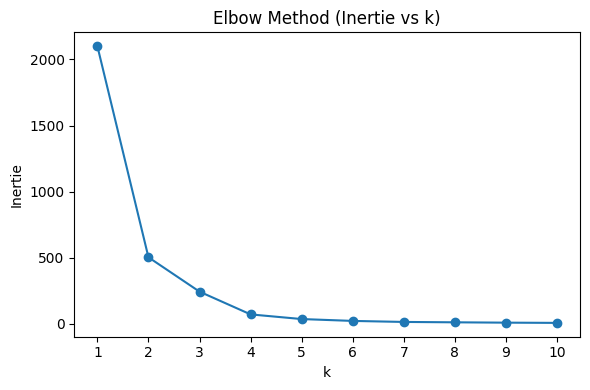

Elbow suggests k = 2


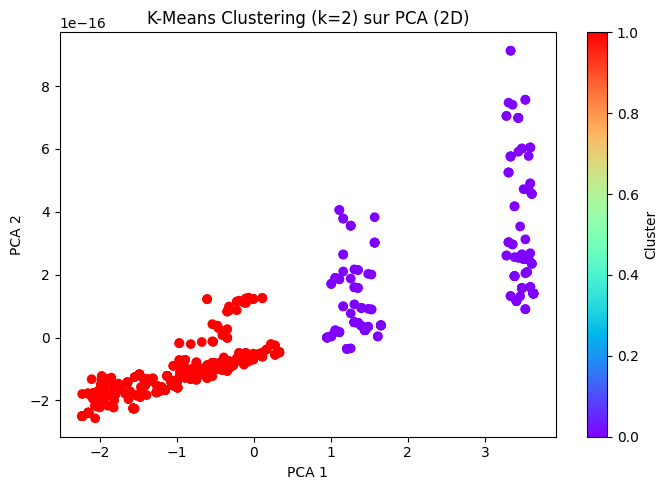

In [4]:
# 1. Sélection des variables pour le clustering
features = new_ratio_cols  # Utilise tous les nouveaux ratios
X = df[features].copy()

# 2. Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Réduction de dimension via PCA à 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance expliquée par les 2 composantes PCA:", pca.explained_variance_ratio_)

# 4. Détermination du nombre optimal de clusters avec la méthode du coude
K_candidates = range(1, 11)
inertias = []
for k_ in K_candidates:
    km_test = KMeans(n_clusters=k_, random_state=42)
    km_test.fit(X_pca)
    inertias.append(km_test.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_candidates, inertias, marker='o')
plt.title('Elbow Method (Inertie vs k)')
plt.xlabel('k')
plt.ylabel('Inertie')
plt.xticks(K_candidates)
plt.tight_layout()
plt.show()

# Calcul naïf du "drop" maximum pour déterminer le k optimal
drops = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
best_drop_index = np.argmax(drops)
best_k = best_drop_index + 1 + 1  # Conversion de l'indice en k
print(f"Elbow suggests k = {best_k}")

# 5. Application finale de K-Means avec k optimal
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='rainbow')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means Clustering (k={best_k}) sur PCA (2D)')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()


**Explication :**  
- Nous sélectionnons tous les nouveaux ratios comme variables pour le clustering.
- Après standardisation, nous appliquons la PCA pour réduire la dimension à 2, facilitant ainsi la visualisation.
- La méthode du coude nous aide à déterminer le nombre optimal de clusters, et nous appliquons K-Means avec ce nombre.
- Le scatter plot affiche la répartition des entreprises selon leurs clusters.


In [5]:
# 6. Analyse des clusters
df['Cluster'] = labels
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nMean of each ratio by cluster:")
print(cluster_summary)

# Création du dossier de sortie s'il n'existe pas déjà
os.makedirs('../data/processed', exist_ok=True)

# Définir le chemin de sauvegarde en utilisant le chemin relatif (ici, "../data/processed")
output_path = os.path.join('../data/processed', 'Financials_clustered_new.csv')
df.to_csv(output_path, index=False)
print(f"\nFichier '{output_path}' enregistré avec la colonne 'Cluster'.")



Mean of each ratio by cluster:
              roa       roe  marge_nette  endettement  liquidite  \
Cluster                                                            
0        0.059314  0.296569     0.593139          4.0   1.666667   
1        0.017087  0.085435     0.170871          4.0   1.666667   

         rotation_actifs  
Cluster                   
0                    0.1  
1                    0.1  

Fichier '../data/processed\Financials_clustered_new.csv' enregistré avec la colonne 'Cluster'.
